# **Análisis topológico de TIM3 en RNC de muestras HNSCC provenientes de pacientes con Anemia de Fanconi**

El enfoque establecido corresponde al propuesto por la Dra Elisa> **¿Qué tipos celulares en el vecindario están asociados con que una célula exprese más Tim-3?**

Se propone analizar la asociación entre la composición del microambiente celular y la expresión del marcador de agotamiento Tim-3 utilizando datos espaciales a resolución de célula individual.

A partir de un dataframe que contiene información morfológica, espacial (coordenadas x/y), anotaciones fenotípicas (FinalPhenotype_ex) y marcadores funcionales (incluyendo estado de Tim-3), se definirán vecindarios celulares alrededor de cada célula utilizando criterios de proximidad espacial (por ejemplo, distancia en micras o vecindarios predefinidos como TSI o RCN).

Para cada célula central perteneciente a un tipo celular j, se cuantificará la abundancia o densidad de cada tipo celular i dentro de su vecindario, considerando los 14–15 tipos celulares anotados en FinalPhenotype_ex. En paralelo, se asignará la expresión de Tim-3 de la célula central (por ejemplo, como variable binaria: TIM3+/TIM3−).

Posteriormente, para cada par de tipos celulares (i, j), se evaluará la asociación entre la abundancia del tipo celular i en el vecindario y la expresión de Tim-3 en células del tipo j, mediante métricas de correlación calculadas sobre el conjunto de vecindarios.

Los valores de asociación se organizarán en matrices de adyacencia, donde cada entrada representará la fuerza y dirección de la relación entre tipos celulares. Estas matrices se interpretarán como grafos dirigidos y ponderados, en los cuales los nodos corresponden a tipos celulares y las aristas reflejan asociaciones espaciales con la expresión de Tim-3.

Finalmente, el análisis se estratificará por variables clínicas disponibles en el dataset (por ejemplo, estadio tumoral, tipo de tejido o condición), con el objetivo de comparar cómo cambian las interacciones celulares asociadas al agotamiento inmunológico en distintos contextos biológicos.

### **Librerías y cargar datos**

In [ ]:
# Installl libraries
#!pip install pandas
#!pip install seaborn
#!pip install matplotlib
#!pip install networkx
#!pip install numpy

In [263]:
# Call libraries
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os

In [19]:
# Directories in Windows
dir_in = r"\\NAS_BMF_LAB\Projects\t-CycIF\t-CycIF_human\08_Results\Datasets\09_SPACE\csv\rcn_exhaustion"
dir_out = r"D:\spatial_transcriptomics\graph_elisa"


In [20]:
# Show files in directory
print("Files in input directory:", os.listdir(dir_in))
print("Files in output data directory:", os.listdir(dir_out))

Files in input directory: ['3_spatial_analyses_scimap_test_raul.ipynb', 'calculations', 'plots', 'RCN_ex_TSI_350um_ROI_only.csv', 'RCN_ex_TSI_350um_ROI_only.h5ad', 'RCN_ex_TSI_350um_ROI_only_updated.csv', 'RCN_neighborhood_graph.h5ad']
Files in output data directory: ['network.ipynb', 'results']


In [22]:
# Read matrix file
data = pd.read_csv(os.path.join(dir_in, "RCN_ex_TSI_350um_ROI_only_updated.csv"))

C:\Users\jhona\AppData\Local\Temp\ipykernel_33632\734927020.py:2: DtypeWarning: Columns (0: Tumor.stage, 1: Smoking, 2: BMT, 3: VPH.status, 4: Desmoplastic.category, 5: TDA, 6: TDA_by_distance, 7: FANC.gene, 8: Desmoplasia) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(dir_in, "RCN_ex_TSI_350um_ROI_only_updated.csv"))


In [23]:
# Show columns in the dataframe
print("Columns in the dataframe:", data.columns)
# Dimension of the dataframe
print("Shape of the dataframe:", data.shape)

Columns in the dataframe: Index(['CellID', 'unique_cellid', 'X_centroid', 'Y_centroid', 'Area',
       'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'Solidity',
       'Extent', 'Orientation', 'Sample', 'Condition', 'Replicate',
       'phenotype', 'FinalPhenotype', 'GlobalCellType', 'Batch', 'Group',
       'Tumor.type', 'Same.patient', 'Tumor.site', 'Tumor.stage',
       'Age.at.diagnosis', 'Smoking', 'Gender', 'BMT', 'VPH.status',
       'Patient.status', 'Desmoplastic.grade', 'Desmoplastic.category', 'tim3',
       'pd_l1', 'pd_1', 'p_s6', 'ki67', 'gh2ax', 'imageid', 'ROI',
       'epithelium_nearest_to_stroma', 'density_filter_epithelium',
       'distance_to_nearest_epithelium', 'stroma_by_distance',
       'stroma_nearest_to_epithelium', 'density_filter_stroma',
       'distance_to_nearest_stroma', 'epithelium_by_distance', 'TDA',
       'TDA_by_distance', 'FANC.gene', 'cluster_kmeans_spatial_count_50',
       'cluster_kmeans_spatial_count_100', 'cluster_kmeans_spatial_c

In [24]:
# Show first few rows of the data, each column
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

display(data.head()) 

,CellID,unique_cellid,X_centroid,Y_centroid,Area,MajorAxisLength,MinorAxisLength,Eccentricity,Solidity,Extent,Orientation,Sample,Condition,Replicate,phenotype,FinalPhenotype,GlobalCellType,Batch,Group,Tumor.type,Same.patient,Tumor.site,Tumor.stage,Age.at.diagnosis,Smoking,Gender,BMT,VPH.status,Patient.status,Desmoplastic.grade,Desmoplastic.category,tim3,pd_l1,pd_1,p_s6,ki67,gh2ax,imageid,ROI,epithelium_nearest_to_stroma,density_filter_epithelium,distance_to_nearest_epithelium,stroma_by_distance,stroma_nearest_to_epithelium,density_filter_stroma,distance_to_nearest_stroma,epithelium_by_distance,TDA,TDA_by_distance,FANC.gene,cluster_kmeans_spatial_count_50,cluster_kmeans_spatial_count_100,cluster_kmeans_spatial_count_150,tissue_section,distance_um,compartment,RCN,x_um,y_um,grid_x,grid_y,FOV_id,FOV_tag,TSI,Desmoplasia,Exhausted_CD8,FinalPhenotype_ex,RCN_ex,cluster_kmeans_spatial_count_100_ex
0,3.0,AGSCC_3_3,35512.947059,55560.686275,1020,53.093709,25.442654,0.877704,0.955056,0.700549,-1.350131,AGSCC_3,AG,1,Ki67+ tumor cells,Ki67+ tumor,Tumor,Human 2025,Non FA,Anogenital,No,Cervix,Stage II,34.0,NaN,female,No,NaN,na,3.0,intermediate,TIM3-,PD-L1-,PD-1-,p-S6-,Ki67+,gH2AX+,AG1,CIS,no,True,NaN,NaN,no,False,65.312621,epithelium_75µm,NaN,NaN,NaN,12,1,2,epithelium_75µm,-75,Epithelium,RCN2,11541.707794,18057.223039,115,180,1.0,AGSCC_3_FOV1_CIS,Epithelium,Intermediate-Mature,0,Tumor,RCN1,7
1,4.0,AGSCC_3_4,23791.363813,25480.863813,514,26.954174,24.297596,0.432902,0.969811,0.790769,-0.687901,AGSCC_3,AG,1,Ki67+ tumor cells,Ki67+ tumor,Tumor,Human 2025,Non FA,Anogenital,No,Cervix,Stage II,34.0,NaN,female,No,NaN,na,3.0,intermediate,TIM3+,PD-L1-,PD-1-,p-S6+,Ki67+,gH2AX-,AG1,HGD,no,True,NaN,NaN,no,False,25.544760,epithelium_50µm,NaN,NaN,NaN,12,6,6,epithelium_50µm,-50,Epithelium,RCN3,7732.193239,8281.280739,77,82,1.0,AGSCC_3_FOV1_HGD,Epithelium,Intermediate-Mature,0,Tumor,RCN1,7
2,5.0,AGSCC_3_5,15946.498110,38053.924386,1058,38.918816,34.739672,0.450812,0.976015,0.816358,-0.793862,AGSCC_3,AG,1,tumor cells,Tumor,Tumor,Human 2025,Non FA,Anogenital,No,Cervix,Stage II,34.0,NaN,female,No,NaN,na,3.0,intermediate,TIM3-,PD-L1-,PD-1-,p-S6+,Ki67-,gH2AX-,AG1,CIS,no,True,NaN,NaN,no,False,17.339718,epithelium_25µm,NaN,NaN,NaN,5,1,15,epithelium_25µm,-25,Epithelium,RCN4,5182.611886,12367.525425,51,123,2.0,AGSCC_3_FOV2_CIS,Epithelium,Intermediate-Mature,0,Tumor,RCN2,0
3,6.0,AGSCC_3_6,27474.656379,13394.082305,486,27.719407,22.367834,0.590637,0.966203,0.788961,-0.179104,AGSCC_3,AG,1,tumor cells,Tumor,Tumor,Human 2025,Non FA,Anogenital,No,Cervix,Stage II,34.0,NaN,female,No,NaN,na,3.0,intermediate,TIM3-,PD-L1-,PD-1-,p-S6-,Ki67-,gH2AX+,AG1,IC,no,True,NaN,NaN,no,False,34.094617,epithelium_50µm,NaN,NaN,NaN,0,6,6,epithelium_50µm,-50,Epithelium,RCN3,8929.263323,4353.076749,89,43,1.0,AGSCC_3_FOV1_IC,Epithelium,Intermediate-Mature,0,Tumor,RCN2,0
4,11.0,AGSCC_3_11,43715.489988,47271.648999,849,37.426818,29.146438,0.627324,0.970286,0.786111,-0.120228,AGSCC_3,AG,1,stromal cells,Stromal,Stromal,Human 2025,Non FA,Anogenital,No,Cervix,Stage II,34.0,NaN,female,No,NaN,na,3.0,intermediate,TIM3-,PD-L1-,PD-1+,p-S6-,Ki67-,gH2AX-,AG1,CIS,no,False,96.165067,stroma_100µm,no,True,NaN,NaN,NaN,NaN,NaN,14,10,14,stroma_100µm,100,Stroma,RCN8,14207.534246,15363.285925,142,153,1.0,AGSCC_3_FOV1_CIS,Stroma,Intermediate-Mature,0,Stromal,RCN9,1


In [60]:
# Show levels of the 'FinalPhenotype', 'tim3' and 'pd_1' columns
print("Unique values in 'FinalPhenotype':", data['FinalPhenotype'].unique())
print()
print("Unique values in 'FinalPhenotype_ex':", data['FinalPhenotype_ex'].unique())
print()
print("Unique values in 'tim3':", data['tim3'].unique())

Unique values in 'FinalPhenotype': <StringArray>
[          'Ki67+ tumor',                 'Tumor',               'Stromal',
 'Effector CD8+ T cells',    'Regulatory T cells',       'Dendritic cells',
                    'NK',           'Endothelial',          'CD4+ T cells',
               'B cells',     'M1/M0 macrophages',        'M2 macrophages',
                 'Other',            'Other APCs',           'Neutrophils',
  'IBA1/HLA-DBP1+ tumor',           'IBA1+ tumor']
Length: 17, dtype: str

Unique values in 'FinalPhenotype_ex': <StringArray>
[                 'Tumor',                'Stromal', 'Exhausted CD8+ T cells',
     'Regulatory T cells',        'Dendritic cells',                     'NK',
            'Endothelial',           'CD4+ T cells',                'B cells',
      'M1/M0 macrophages',         'M2 macrophages',  'Effector CD8+ T cells',
                  'Other',             'Other APCs',            'Neutrophils']
Length: 15, dtype: str

Unique values in 'tim3': 

In [61]:
# Show values of 'FinalPhenotype' column
print("Values in 'FinalPhenotype' column:", data['FinalPhenotype'].value_counts())
print()
print("Values in 'FinalPhenotype_ex' column:", data['FinalPhenotype_ex'].value_counts())

Values in 'FinalPhenotype' column: FinalPhenotype
Tumor                    2318527
Stromal                  1843103
Ki67+ tumor              1240406
Effector CD8+ T cells     603205
Endothelial               499849
CD4+ T cells              464166
Regulatory T cells        439940
M2 macrophages            413729
Neutrophils               266594
Dendritic cells           187245
M1/M0 macrophages         180845
B cells                   174935
IBA1+ tumor               123584
Other APCs                112184
NK                         79224
Other                      50127
IBA1/HLA-DBP1+ tumor       36454
Name: count, dtype: int64

Values in 'FinalPhenotype_ex' column: FinalPhenotype_ex
Tumor                     3718971
Stromal                   1843103
Endothelial                499849
CD4+ T cells               464166
Regulatory T cells         439940
M2 macrophages             413729
Exhausted CD8+ T cells     357867
Neutrophils                266594
Effector CD8+ T cells      245338


In [62]:
# Ver un ejemplo de la tabla con los datos de 'FinalPhenotype_ex', 'tim3' y 'pd_1' de cada tipo de célula
print("Example of 'FinalPhenotype', 'tim3' and 'pd_1' columns:")
print(data[['FinalPhenotype', 'tim3', 'pd_1']].head())
print()
print("Example of 'FinalPhenotype_ex', 'tim3' and 'pd_1' columns:")
print(data[['FinalPhenotype_ex', 'tim3', 'pd_1']].head())

Example of 'FinalPhenotype', 'tim3' and 'pd_1' columns:
  FinalPhenotype   tim3   pd_1
0    Ki67+ tumor  TIM3-  PD-1-
1    Ki67+ tumor  TIM3+  PD-1-
2          Tumor  TIM3-  PD-1-
3          Tumor  TIM3-  PD-1-
4        Stromal  TIM3-  PD-1+

Example of 'FinalPhenotype_ex', 'tim3' and 'pd_1' columns:
  FinalPhenotype_ex   tim3   pd_1
0             Tumor  TIM3-  PD-1-
1             Tumor  TIM3+  PD-1-
2             Tumor  TIM3-  PD-1-
3             Tumor  TIM3-  PD-1-
4           Stromal  TIM3-  PD-1+


In [63]:
# Clean data 
# Copy the original data to avoid modifying it directly
data_clean = data.copy()

# 1. Join tumor categories into one "Tumor"
tumor_categories = [
    "Ki67+ tumor",
    "Tumor",
    "IBA1/HLA-DBP1+ tumor",
    "IBA1+ tumor"
]

def collapse_cell_types(x):
    if x in tumor_categories:
        return "Tumor"
    else:
        return x

data_clean['cell_type'] = data_clean['FinalPhenotype'].apply(collapse_cell_types)

# 2. Remove "Other"
data_clean = data_clean[data_clean['cell_type'] != 'Other']

# 3. Convert 'tim3' to binary (1 for 'TIM3+', 0 for 'TIM3-') because now is "tim3 = 'TIM3+' o 'TIM3-'"
data_clean['tim3_binary'] = (data_clean['tim3'] == 'TIM3+').astype(int)


In [73]:
# New columns in the cleaned data
print(data_clean.columns)
print(data_clean.shape)

Index(['CellID', 'unique_cellid', 'X_centroid', 'Y_centroid', 'Area',
       'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'Solidity',
       'Extent', 'Orientation', 'Sample', 'Condition', 'Replicate',
       'phenotype', 'FinalPhenotype', 'GlobalCellType', 'Batch', 'Group',
       'Tumor.type', 'Same.patient', 'Tumor.site', 'Tumor.stage',
       'Age.at.diagnosis', 'Smoking', 'Gender', 'BMT', 'VPH.status',
       'Patient.status', 'Desmoplastic.grade', 'Desmoplastic.category', 'tim3',
       'pd_l1', 'pd_1', 'p_s6', 'ki67', 'gh2ax', 'imageid', 'ROI',
       'epithelium_nearest_to_stroma', 'density_filter_epithelium',
       'distance_to_nearest_epithelium', 'stroma_by_distance',
       'stroma_nearest_to_epithelium', 'density_filter_stroma',
       'distance_to_nearest_stroma', 'epithelium_by_distance', 'TDA',
       'TDA_by_distance', 'FANC.gene', 'cluster_kmeans_spatial_count_50',
       'cluster_kmeans_spatial_count_100', 'cluster_kmeans_spatial_count_150',
       'tissue_

In [67]:
# Show first few rows of the data, each column
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

display(data_clean.head())

,CellID,unique_cellid,X_centroid,Y_centroid,Area,MajorAxisLength,MinorAxisLength,Eccentricity,Solidity,Extent,Orientation,Sample,Condition,Replicate,phenotype,FinalPhenotype,GlobalCellType,Batch,Group,Tumor.type,Same.patient,Tumor.site,Tumor.stage,Age.at.diagnosis,Smoking,Gender,BMT,VPH.status,Patient.status,Desmoplastic.grade,Desmoplastic.category,tim3,pd_l1,pd_1,p_s6,ki67,gh2ax,imageid,ROI,epithelium_nearest_to_stroma,density_filter_epithelium,distance_to_nearest_epithelium,stroma_by_distance,stroma_nearest_to_epithelium,density_filter_stroma,distance_to_nearest_stroma,epithelium_by_distance,TDA,TDA_by_distance,FANC.gene,cluster_kmeans_spatial_count_50,cluster_kmeans_spatial_count_100,cluster_kmeans_spatial_count_150,tissue_section,distance_um,compartment,RCN,x_um,y_um,grid_x,grid_y,FOV_id,FOV_tag,TSI,Desmoplasia,Exhausted_CD8,FinalPhenotype_ex,RCN_ex,cluster_kmeans_spatial_count_100_ex,cell_type,tim3_binary
0,3.0,AGSCC_3_3,35512.947059,55560.686275,1020,53.093709,25.442654,0.877704,0.955056,0.700549,-1.350131,AGSCC_3,AG,1,Ki67+ tumor cells,Ki67+ tumor,Tumor,Human 2025,Non FA,Anogenital,No,Cervix,Stage II,34.0,NaN,female,No,NaN,na,3.0,intermediate,TIM3-,PD-L1-,PD-1-,p-S6-,Ki67+,gH2AX+,AG1,CIS,no,True,NaN,NaN,no,False,65.312621,epithelium_75µm,NaN,NaN,NaN,12,1,2,epithelium_75µm,-75,Epithelium,RCN2,11541.707794,18057.223039,115,180,1.0,AGSCC_3_FOV1_CIS,Epithelium,Intermediate-Mature,0,Tumor,RCN1,7,Tumor,0
1,4.0,AGSCC_3_4,23791.363813,25480.863813,514,26.954174,24.297596,0.432902,0.969811,0.790769,-0.687901,AGSCC_3,AG,1,Ki67+ tumor cells,Ki67+ tumor,Tumor,Human 2025,Non FA,Anogenital,No,Cervix,Stage II,34.0,NaN,female,No,NaN,na,3.0,intermediate,TIM3+,PD-L1-,PD-1-,p-S6+,Ki67+,gH2AX-,AG1,HGD,no,True,NaN,NaN,no,False,25.544760,epithelium_50µm,NaN,NaN,NaN,12,6,6,epithelium_50µm,-50,Epithelium,RCN3,7732.193239,8281.280739,77,82,1.0,AGSCC_3_FOV1_HGD,Epithelium,Intermediate-Mature,0,Tumor,RCN1,7,Tumor,1
2,5.0,AGSCC_3_5,15946.498110,38053.924386,1058,38.918816,34.739672,0.450812,0.976015,0.816358,-0.793862,AGSCC_3,AG,1,tumor cells,Tumor,Tumor,Human 2025,Non FA,Anogenital,No,Cervix,Stage II,34.0,NaN,female,No,NaN,na,3.0,intermediate,TIM3-,PD-L1-,PD-1-,p-S6+,Ki67-,gH2AX-,AG1,CIS,no,True,NaN,NaN,no,False,17.339718,epithelium_25µm,NaN,NaN,NaN,5,1,15,epithelium_25µm,-25,Epithelium,RCN4,5182.611886,12367.525425,51,123,2.0,AGSCC_3_FOV2_CIS,Epithelium,Intermediate-Mature,0,Tumor,RCN2,0,Tumor,0
3,6.0,AGSCC_3_6,27474.656379,13394.082305,486,27.719407,22.367834,0.590637,0.966203,0.788961,-0.179104,AGSCC_3,AG,1,tumor cells,Tumor,Tumor,Human 2025,Non FA,Anogenital,No,Cervix,Stage II,34.0,NaN,female,No,NaN,na,3.0,intermediate,TIM3-,PD-L1-,PD-1-,p-S6-,Ki67-,gH2AX+,AG1,IC,no,True,NaN,NaN,no,False,34.094617,epithelium_50µm,NaN,NaN,NaN,0,6,6,epithelium_50µm,-50,Epithelium,RCN3,8929.263323,4353.076749,89,43,1.0,AGSCC_3_FOV1_IC,Epithelium,Intermediate-Mature,0,Tumor,RCN2,0,Tumor,0
4,11.0,AGSCC_3_11,43715.489988,47271.648999,849,37.426818,29.146438,0.627324,0.970286,0.786111,-0.120228,AGSCC_3,AG,1,stromal cells,Stromal,Stromal,Human 2025,Non FA,Anogenital,No,Cervix,Stage II,34.0,NaN,female,No,NaN,na,3.0,intermediate,TIM3-,PD-L1-,PD-1+,p-S6-,Ki67-,gH2AX-,AG1,CIS,no,False,96.165067,stroma_100µm,no,True,NaN,NaN,NaN,NaN,NaN,14,10,14,stroma_100µm,100,Stroma,RCN8,14207.534246,15363.285925,142,153,1.0,AGSCC_3_FOV1_CIS,Stroma,Intermediate-Mature,0,Stromal,RCN9,1,Stromal,0


In [68]:
# Number of cells per cell type in the cleaned data
data_clean['cell_type'].value_counts()

cell_type
Tumor                    3718971
Stromal                  1843103
Effector CD8+ T cells     603205
Endothelial               499849
CD4+ T cells              464166
Regulatory T cells        439940
M2 macrophages            413729
Neutrophils               266594
Dendritic cells           187245
M1/M0 macrophages         180845
B cells                   174935
Other APCs                112184
NK                         79224
Name: count, dtype: int64

In [69]:
# Show TIM3
data_clean['tim3_binary'].value_counts(normalize=True)

tim3_binary
0    0.815242
1    0.184758
Name: proportion, dtype: float64

In [70]:
# Exploration of the relationship between cell type and TIM3 expression
pd.crosstab(data_clean['cell_type'], data_clean['tim3_binary'], normalize='index')

tim3_binary,0,1
cell_type,,
B cells,0.826747,0.173253
CD4+ T cells,0.722879,0.277121
Dendritic cells,0.561943,0.438057
Effector CD8+ T cells,0.608299,0.391701
Endothelial,0.878319,0.121681
M1/M0 macrophages,0.712533,0.287467
M2 macrophages,0.756718,0.243282
NK,0.575823,0.424177
Neutrophils,0.859941,0.140059


### **Análisis de los RCN**

Trabajando con un subset de células, solo para montar el flujo  de trabajo.

In [102]:
# Subset data 
data_clean = data_clean.copy()

dfs = []

for ct, df_ct in data_clean.groupby('cell_type'):
    n = min(len(df_ct), 40000)  # If there are less than 40,000 cells of this type, take all of them
    df_sampled = df_ct.sample(n=n, random_state=42)
    dfs.append(df_sampled)

# Join all sampled dataframes into one
data_sample = pd.concat(dfs, ignore_index=True)

# Veification of sample data
print("Conteo por tipo celular:")
print()
print(data_sample['cell_type'].value_counts())
print()
print("Shape final:")
print(data_sample.shape)

Conteo por tipo celular:

cell_type
B cells                  40000
CD4+ T cells             40000
Dendritic cells          40000
Effector CD8+ T cells    40000
Endothelial              40000
M1/M0 macrophages        40000
M2 macrophages           40000
NK                       40000
Neutrophils              40000
Other APCs               40000
Regulatory T cells       40000
Stromal                  40000
Tumor                    40000
Name: count, dtype: int64

Shape final:
(520000, 71)


In [103]:
# RCN composition: per RNC we want celltype proportion and TIM3 expression 
# Cell count per RCN and cell type
rcn_counts = (
    data_sample
    .groupby(['RCN', 'cell_type'])
    .size()
    .unstack(fill_value=0)
)

# Make a proportion 
rcn_props = rcn_counts.div(rcn_counts.sum(axis=1), axis=0)

print("Shape composición (RCN x cell types):", rcn_props.shape)
display(rcn_props.head())

Shape composición (RCN x cell types): (16, 13)


cell_type,B cells,CD4+ T cells,Dendritic cells,Effector CD8+ T cells,Endothelial,M1/M0 macrophages,M2 macrophages,NK,Neutrophils,Other APCs,Regulatory T cells,Stromal,Tumor
RCN,,,,,,,,,,,,,
RCN1,0.004303,0.035723,0.045449,0.025701,0.010021,0.053171,0.034190,0.040910,0.110116,0.061306,0.010905,0.018981,0.549222
RCN10,0.054425,0.115393,0.098673,0.050425,0.086502,0.079455,0.090952,0.059451,0.043897,0.101060,0.082642,0.129164,0.007960
RCN11,0.056972,0.080590,0.091130,0.074182,0.076166,0.115413,0.146770,0.111697,0.049732,0.087066,0.068621,0.036363,0.005298
RCN12,0.119617,0.063796,0.138103,0.069822,0.036837,0.062028,0.039623,0.055617,0.038377,0.090777,0.243538,0.038218,0.003647
RCN13,0.025518,0.025278,0.038278,0.018984,0.019775,0.021976,0.035664,0.029061,0.673075,0.055370,0.022045,0.021873,0.013103


In [105]:
# How many RCN we have?
print("Number of unique RCN:", data_sample['RCN'].nunique())
#How many cell types we have? And wich are they?
print("Unique cell types:", data_sample['cell_type'].unique())

Number of unique RCN: 16
Unique cell types: <StringArray>
[              'B cells',          'CD4+ T cells',       'Dendritic cells',
 'Effector CD8+ T cells',           'Endothelial',     'M1/M0 macrophages',
        'M2 macrophages',                    'NK',           'Neutrophils',
            'Other APCs',    'Regulatory T cells',               'Stromal',
                 'Tumor']
Length: 13, dtype: str


Figure saved as: D:\spatial_transcriptomics\graph_elisa\rcn_celltype_proportions.svg


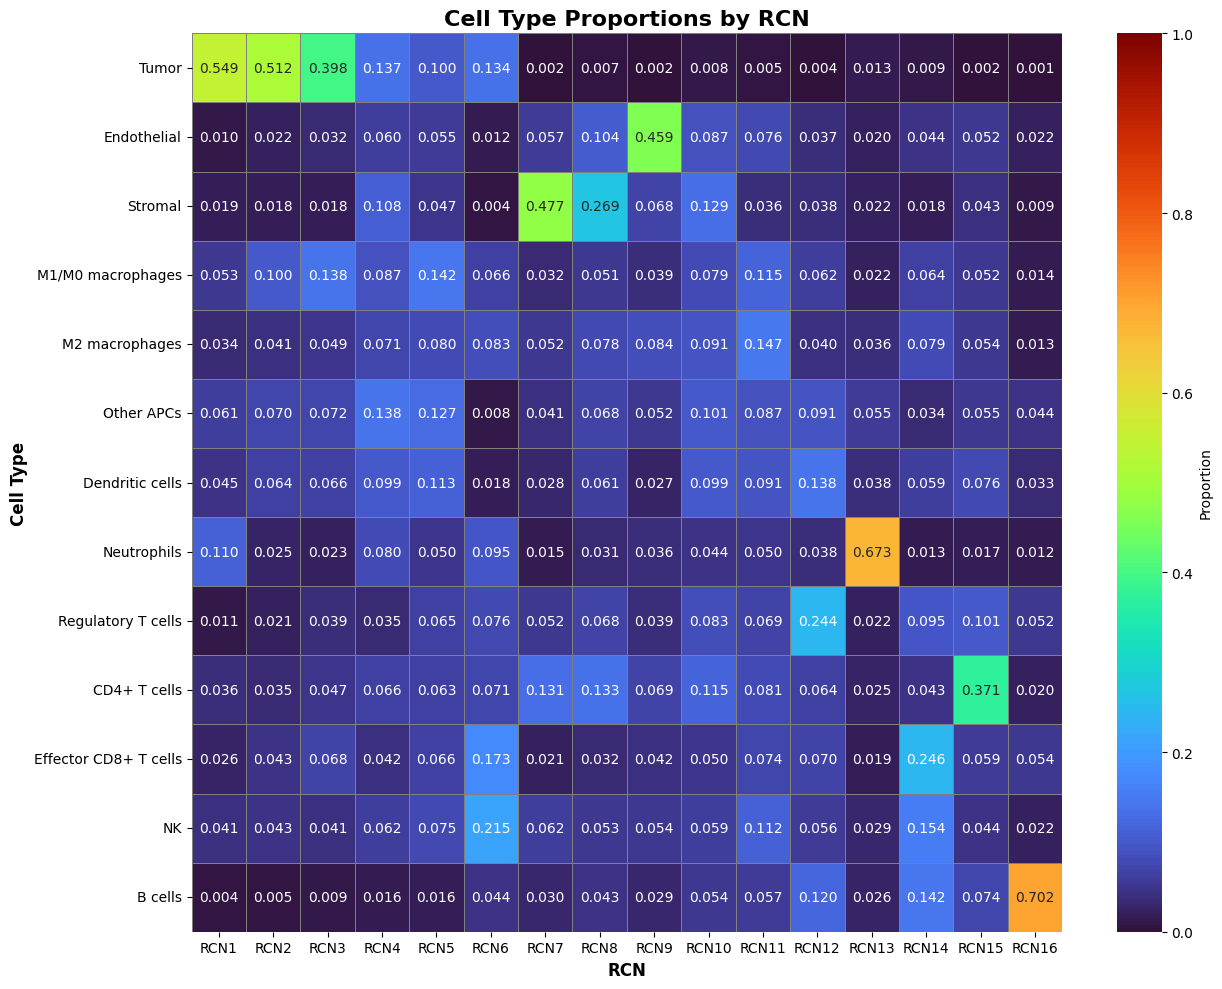

In [166]:
# Transpose rcn_props so rows are cell types and columns are RCNs
# Define cell type order (biological order from tumor center to periphery)
cell_type_order = [
    'Tumor',
    'Endothelial',
    'Stromal',
    'M1/M0 macrophages',
    'M2 macrophages',
    'Other APCs',
    'Dendritic cells',
    'Neutrophils',
    'Regulatory T cells',
    'CD4+ T cells',
    'Effector CD8+ T cells',
    'NK',
    'B cells'
]

# Reorder RCNs from 1 to 16
rcn_order = [f'RCN{i}' for i in range(1, 17)]

# Reorder the dataframe
rcn_props_ordered = rcn_props.loc[rcn_order, cell_type_order]

# Create figure with larger size
fig, ax = plt.subplots(figsize=(13, 10))

# Create heatmap with better parameters
sns.heatmap(
    rcn_props_ordered.T,
    annot=True,
    cmap='turbo',
    fmt='.3f',
    cbar_kws={'label': 'Proportion'},
    linewidths=0.5,
    linecolor='gray',
    ax=ax, vmin=0, vmax=1
)

ax.set_title('Cell Type Proportions by RCN', fontsize=16, fontweight='bold')
ax.set_xlabel('RCN', fontsize=12, fontweight='bold')
ax.set_ylabel('Cell Type', fontsize=12, fontweight='bold')

plt.tight_layout()

# Save as SVG
output_file = os.path.join(dir_out, 'rcn_celltype_proportions.svg')
plt.savefig(output_file, format='svg', dpi=1200, bbox_inches='tight')
print(f"Figure saved as: {output_file}")

plt.show()

In [143]:
# TIM3 expression per RCN
rcn_tim3 = (
    data_sample
    .groupby('RCN')['tim3_binary']
    .mean()
)

print("Shape TIM3:", rcn_tim3.shape)
display(rcn_tim3.head())

Shape TIM3: (16,)


RCN
RCN1     0.203667
RCN10    0.219611
RCN11    0.288326
RCN12    0.419157
RCN13    0.199436
Name: tim3_binary, dtype: float64

Figure saved as: D:\spatial_transcriptomics\graph_elisa\rcn_tim3_expression.svg


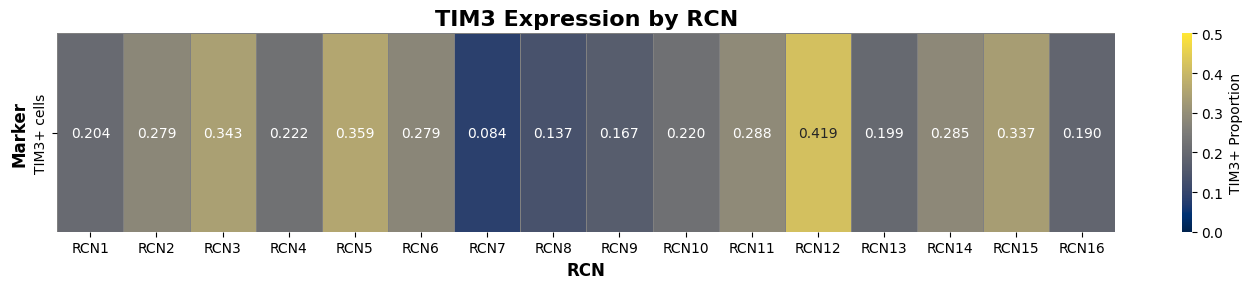

In [183]:
# TIM3 expression by RCN - Create heatmap
# Reshape rcn_tim3 to a 2D array for heatmap (1 row for TIM3)
rcn_tim3_data = rcn_tim3.loc[rcn_order].values.reshape(1, -1)

# Create figure with larger size
fig, ax = plt.subplots(figsize=(14, 3))

# Create heatmap
sns.heatmap(
    rcn_tim3_data,
    annot=True,
    cmap='cividis',
    fmt='.3f',
    cbar_kws={'label': 'TIM3+ Proportion'},
    linewidths=0.5, linecolor='gray',
    ax=ax, vmin=0, vmax=0.5,
    xticklabels=rcn_order, yticklabels=['TIM3+ cells']
)

ax.set_title('TIM3 Expression by RCN', fontsize=16, fontweight='bold')
ax.set_xlabel('RCN', fontsize=12, fontweight='bold')
ax.set_ylabel('Marker', fontsize=12, fontweight='bold')

plt.tight_layout()

# Save as SVG
output_file = os.path.join(dir_out, 'rcn_tim3_expression.svg')
plt.savefig(output_file, format='svg', dpi=1200, bbox_inches='tight')
print(f"Figure saved as: {output_file}")

plt.show()

C:\Users\jhona\AppData\Local\Temp\ipykernel_33632\3221147604.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


Figure saved as: D:\spatial_transcriptomics\graph_elisa\rcn_tim3_barplot.svg


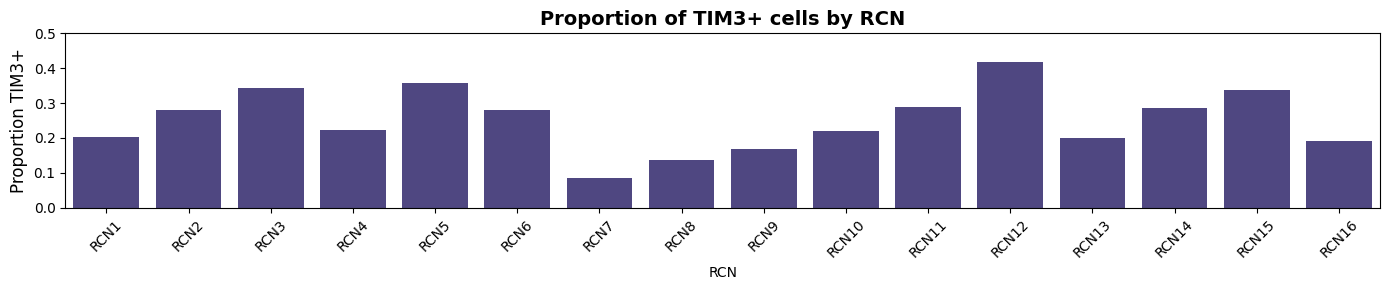

In [200]:
# Alternative visualization TIM3 by RCN

fig, ax = plt.subplots(figsize=(14, 3))

sns.barplot(
    x='RCN',
    y='tim3_binary',
    data=data_sample,
    order=rcn_order,
    ci=None,
    color='darkslateblue',
    ax=ax
)

ax.set_title('Proportion of TIM3+ cells by RCN', fontsize=14, fontweight='bold')
ax.set_ylabel('Proportion TIM3+', fontsize=12)
#ax.set_xlabel('RCN', fontsize=12)
ax.set_ylim(0,0.5)
plt.xticks(rotation=45)
plt.tight_layout()

output_file = os.path.join(dir_out, 'rcn_tim3_barplot.svg')
plt.savefig(output_file, format='svg', dpi=1200, bbox_inches='tight')
print(f"Figure saved as: {output_file}")
plt.show()

In [201]:
# Join X and Y for correlation
rcn_data = rcn_props.copy()
rcn_data['tim3_mean'] = rcn_tim3

print("Shape final:", rcn_data.shape)
display(rcn_data.head())

Shape final: (16, 14)


cell_type,B cells,CD4+ T cells,Dendritic cells,Effector CD8+ T cells,Endothelial,M1/M0 macrophages,M2 macrophages,NK,Neutrophils,Other APCs,Regulatory T cells,Stromal,Tumor,tim3_mean
RCN,,,,,,,,,,,,,,
RCN1,0.004303,0.035723,0.045449,0.025701,0.010021,0.053171,0.034190,0.040910,0.110116,0.061306,0.010905,0.018981,0.549222,0.203667
RCN10,0.054425,0.115393,0.098673,0.050425,0.086502,0.079455,0.090952,0.059451,0.043897,0.101060,0.082642,0.129164,0.007960,0.219611
RCN11,0.056972,0.080590,0.091130,0.074182,0.076166,0.115413,0.146770,0.111697,0.049732,0.087066,0.068621,0.036363,0.005298,0.288326
RCN12,0.119617,0.063796,0.138103,0.069822,0.036837,0.062028,0.039623,0.055617,0.038377,0.090777,0.243538,0.038218,0.003647,0.419157
RCN13,0.025518,0.025278,0.038278,0.018984,0.019775,0.021976,0.035664,0.029061,0.673075,0.055370,0.022045,0.021873,0.013103,0.199436


In [202]:
# Correlation between cell types and TIM3 expression across RCNs
correlations = rcn_data.corr()['tim3_mean'].drop('tim3_mean')

print("Correlaciones con TIM3:")
print(correlations.sort_values(ascending=False))

Correlaciones con TIM3:
cell_type
Dendritic cells          0.652710
M1/M0 macrophages        0.593908
Regulatory T cells       0.566390
Effector CD8+ T cells    0.362768
Other APCs               0.278154
NK                       0.186812
Tumor                    0.137477
CD4+ T cells             0.081315
M2 macrophages           0.059945
B cells                 -0.094001
Neutrophils             -0.149891
Endothelial             -0.295891
Stromal                 -0.640303
Name: tim3_mean, dtype: float64


C:\Users\jhona\AppData\Local\Temp\ipykernel_33632\2296625667.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('cividis')
C:\Users\jhona\AppData\Local\Temp\ipykernel_33632\2296625667.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\jhona\AppData\Local\Temp\ipykernel_33632\2296625667.py:11: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(


Figure saved as: D:\spatial_transcriptomics\graph_elisa\correlation_celltype_tim3.svg


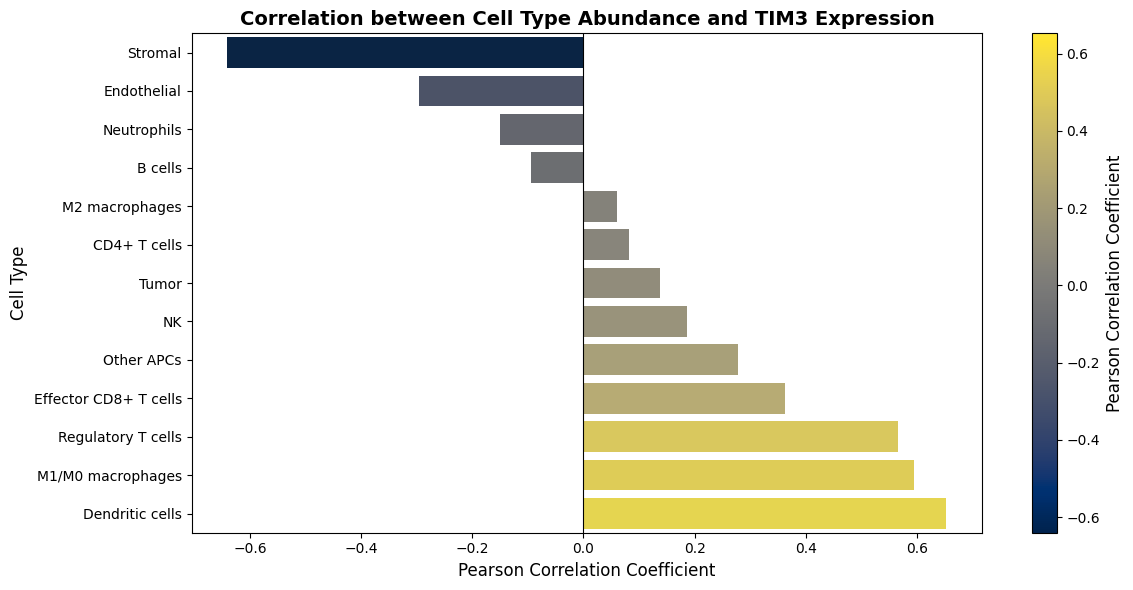

In [222]:
# Visualize correlations with TIM3 expression as a bar plot
fig, ax = plt.subplots(figsize=(12, 6))

correlations_sorted = correlations.sort_values(ascending=True)

# Map correlation values to colors and add a colorbar
norm = plt.Normalize(vmin=correlations_sorted.min(), vmax=correlations_sorted.max())
cmap = plt.cm.get_cmap('cividis')
bar_colors = cmap(norm(correlations_sorted.values))

sns.barplot(
    x=correlations_sorted.values,
    y=correlations_sorted.index,
    palette=bar_colors,
    ax=ax
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Pearson Correlation Coefficient', fontsize=12)

ax.set_title('Correlation between Cell Type Abundance and TIM3 Expression', fontsize=14, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient', fontsize=12)
ax.set_ylabel('Cell Type', fontsize=12)
ax.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()

# Save as SVG
output_file = os.path.join(dir_out, 'correlation_celltype_tim3.svg')
plt.savefig(output_file, format='svg', dpi=1200, bbox_inches='tight')
print(f"Figure saved as: {output_file}")

plt.show()

In [223]:
def compute_correlations_for_target(data, target_cell):
    
    # 1. Subset de células tipo j
    data_j = data[data['cell_type'] == target_cell]
    
    # 2. RCN with those cells
    valid_rcn = data_j['RCN'].unique()
    
    # 3. Subset of relevant neighborhoods
    data_subset = data[data['RCN'].isin(valid_rcn)]
    
    # 4. Composition by RCN (X)
    rcn_counts = (
        data_subset
        .groupby(['RCN', 'cell_type'])
        .size()
        .unstack(fill_value=0)
    )
    
    rcn_props = rcn_counts.div(rcn_counts.sum(axis=1), axis=0)
    
    # 5. TIM3 in J cells (Y)
    rcn_tim3_j = (
        data_j
        .groupby('RCN')['tim3_binary']
        .mean()
    )
    
    # 6. Join X + Y
    rcn_data = rcn_props.copy()
    rcn_data['tim3_mean_j'] = rcn_tim3_j
    
    rcn_data = rcn_data.dropna()
    
    # 7. Correlation between cell types and TIM3 expression across RCNs
    corrs = rcn_data.corr()['tim3_mean_j'].drop('tim3_mean_j')
    
    return corrs

In [224]:
# Build matrix
cell_types = data_sample['cell_type'].unique()

adj_matrix = pd.DataFrame(index=cell_types, columns=cell_types)

for target in cell_types:
    print(f"Processing: {target}")
    
    corrs = compute_correlations_for_target(data_sample, target)
    
    adj_matrix[target] = corrs 

Processing: B cells
Processing: CD4+ T cells
Processing: Dendritic cells
Processing: Effector CD8+ T cells
Processing: Endothelial
Processing: M1/M0 macrophages
Processing: M2 macrophages
Processing: NK
Processing: Neutrophils
Processing: Other APCs
Processing: Regulatory T cells
Processing: Stromal
Processing: Tumor


In [227]:
# Show adjacency matrix
print("Adjacency matrix (correlations):")
display(adj_matrix)

Adjacency matrix (correlations):


,B cells,CD4+ T cells,Dendritic cells,Effector CD8+ T cells,Endothelial,M1/M0 macrophages,M2 macrophages,NK,Neutrophils,Other APCs,Regulatory T cells,Stromal,Tumor
B cells,-0.010690,-0.165567,-0.332029,-0.347755,0.263364,-0.105261,-0.106369,-0.081304,0.306819,-0.356878,-0.290186,0.461746,-0.102886
CD4+ T cells,0.158137,-0.205174,0.059500,-0.305668,-0.046089,-0.084349,-0.301570,-0.038255,-0.225583,0.367032,-0.282223,-0.213765,0.260826
Dendritic cells,0.073137,0.289061,0.221336,0.164457,0.510738,0.500984,0.442791,0.295727,0.595362,0.581182,0.282765,0.404927,0.424995
Effector CD8+ T cells,-0.078110,0.065058,-0.131748,0.088662,-0.290786,-0.344732,-0.192299,0.246677,-0.022041,-0.591456,-0.127854,0.263195,-0.115691
Endothelial,-0.108351,-0.190016,-0.368132,-0.370393,0.028597,-0.366250,-0.327629,-0.276361,-0.143816,-0.114253,-0.261741,-0.105431,0.671585
M1/M0 macrophages,-0.116484,0.673849,0.243255,0.615119,-0.269197,0.540746,0.492843,0.634669,0.127108,0.256963,0.533741,-0.075013,-0.015146
M2 macrophages,-0.229310,-0.159382,-0.118938,-0.171536,-0.189409,-0.346833,-0.370431,-0.125027,-0.308098,-0.220269,-0.273626,-0.157605,0.142213
NK,-0.213111,-0.150376,-0.004680,0.021555,-0.401047,-0.525347,-0.410408,0.055950,-0.279285,-0.626812,-0.268759,0.085083,-0.231943
Neutrophils,0.683394,0.012768,0.548842,0.288259,0.278794,-0.075127,0.094134,-0.154229,-0.087000,-0.171711,0.335647,-0.031909,-0.285465
Other APCs,-0.060197,0.227859,0.058349,0.184022,0.302984,0.442181,0.323083,0.118472,0.289530,0.562855,0.279279,0.025943,0.264804


Figure saved as: D:\spatial_transcriptomics\graph_elisa\adj_matrix_tim3_correlations.svg


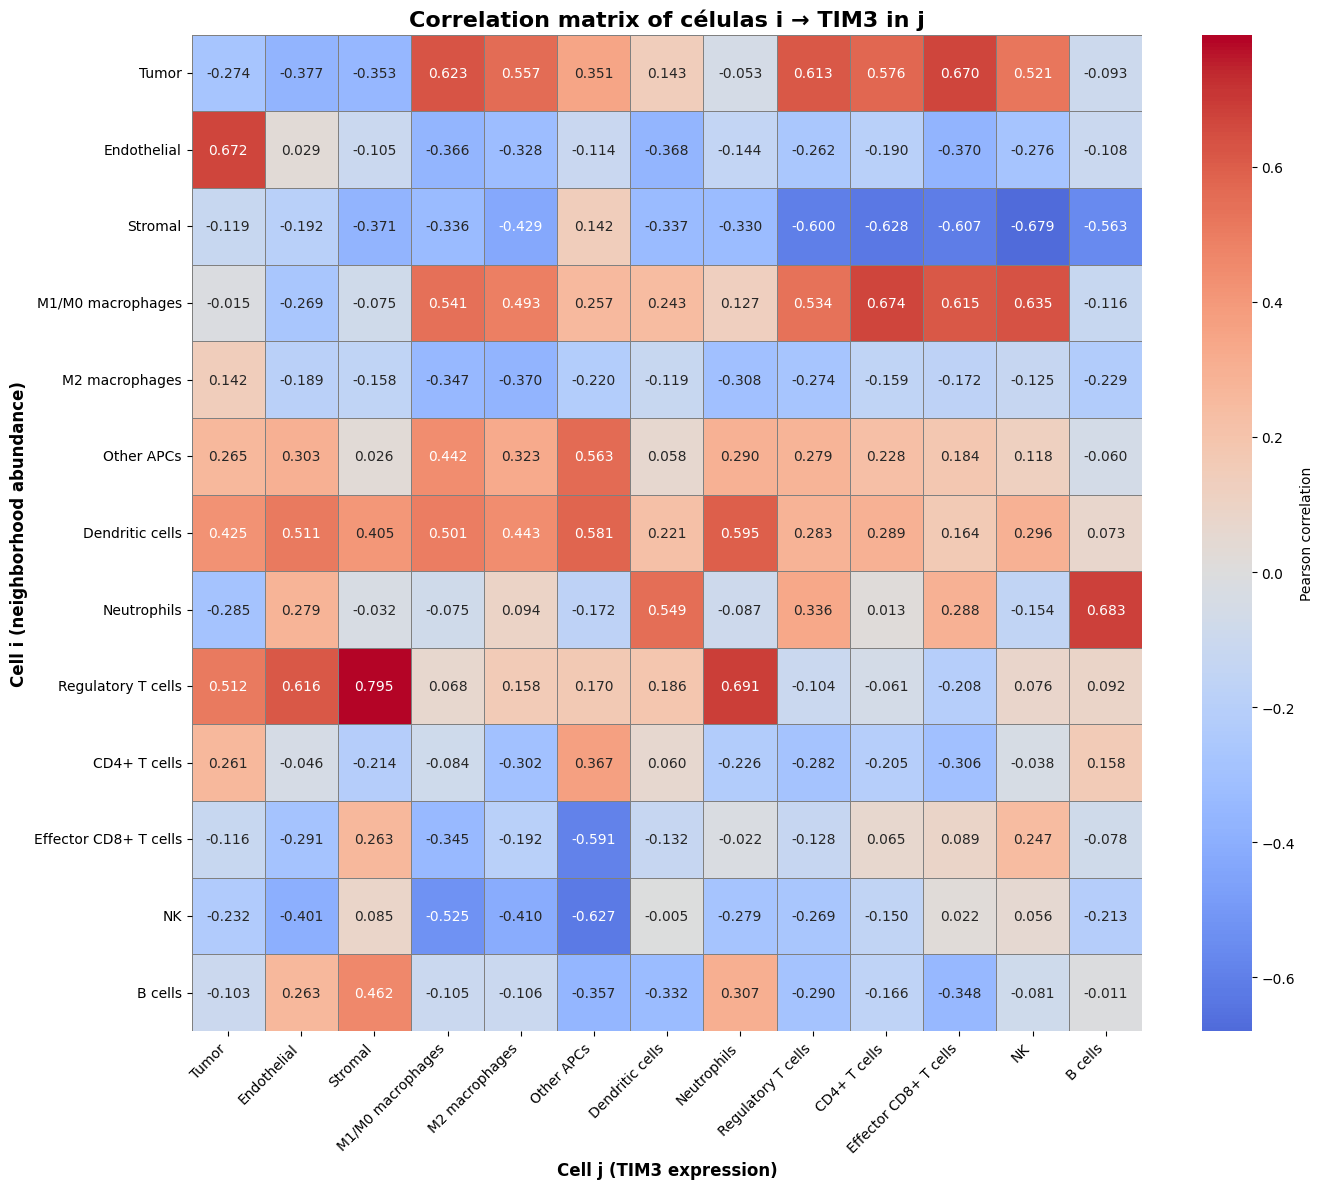

In [245]:

# Visualize adjacency matrix as a heatmap
cell_order = [ct for ct in cell_type_order if ct in adj_matrix.index]
if len(cell_order) == 0:
    cell_order = list(adj_matrix.index)

adj_matrix_plot = adj_matrix.loc[cell_order, cell_order].astype(float)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    adj_matrix_plot,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.3f',
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Pearson correlation'}
)

ax.set_title('Correlation matrix of células i → TIM3 in j', fontsize=16, fontweight='bold')
ax.set_xlabel('Cell j (TIM3 expression)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cell i (neighborhood abundance)', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

output_file = os.path.join(dir_out, 'adj_matrix_tim3_correlations.svg')
plt.savefig(output_file, format='svg', dpi=1200, bbox_inches='tight')
print(f"Figure saved as: {output_file}")

plt.show()

### **Análisis topológico**

In [247]:
# Copy adjacency matrix to create graph
G_matrix = adj_matrix.copy()

# Remove NaNs
G_matrix = G_matrix.fillna(0)

# Filter weak correlations
threshold = 0.3
G_matrix_filtered = G_matrix.where(abs(G_matrix) >= threshold, 0)

In [250]:
# Build directed graph from adjacency matrix
G = nx.DiGraph()

# Add nodes
for cell in G_matrix_filtered.index:
    G.add_node(cell)

# Add edges
for i in G_matrix_filtered.index:      # row = source (i)
    for j in G_matrix_filtered.columns:  # column= target (j)
        weight = G_matrix_filtered.loc[i, j]
        
        if weight != 0:
            G.add_edge(i, j, weight=weight)

Graph saved as: D:\spatial_transcriptomics\graph_elisa\tim3_graph.svg


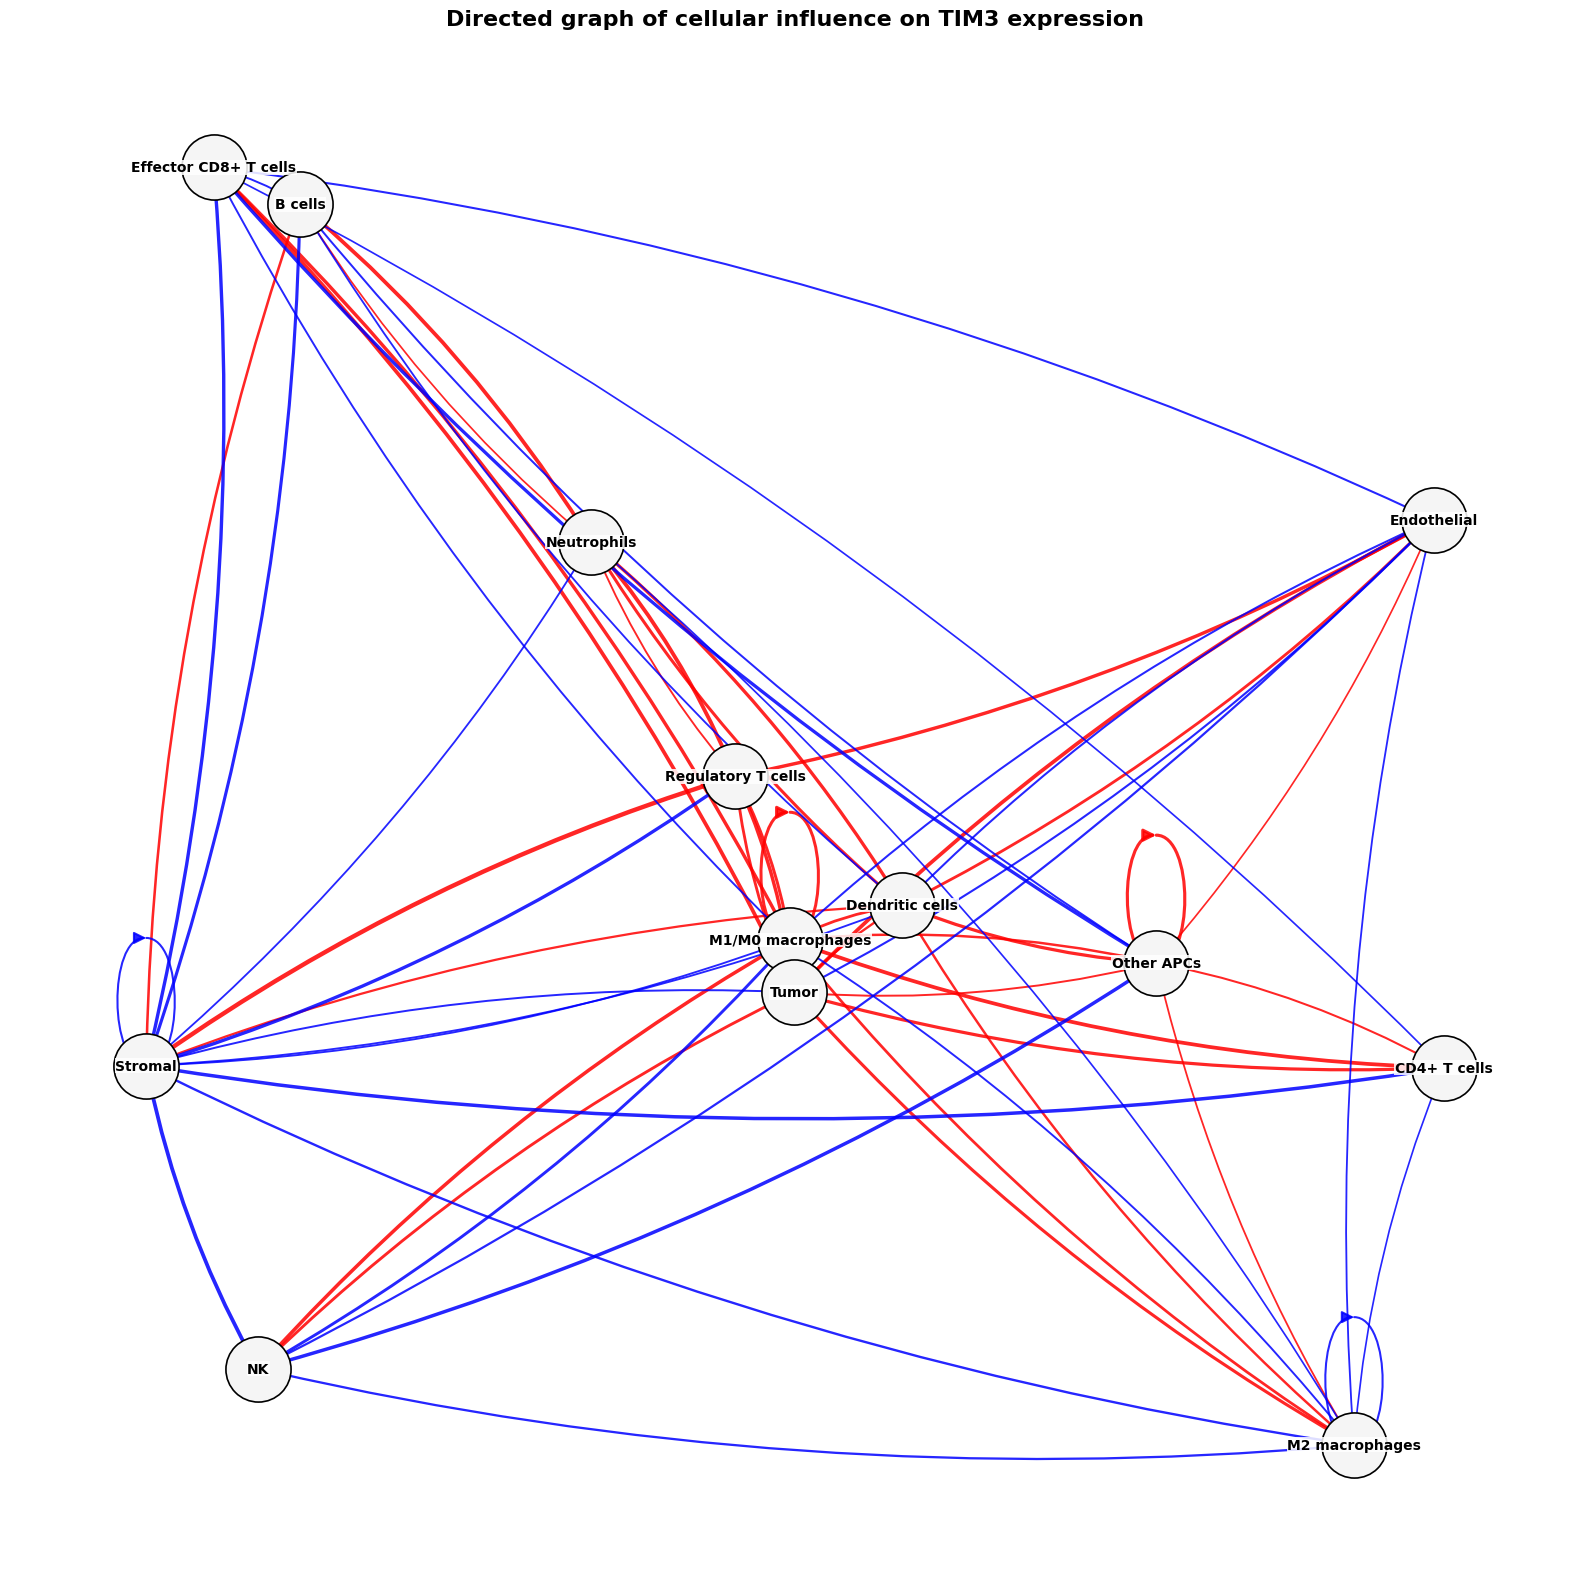

In [257]:
# Visualize the graph and save it
plt.figure(figsize=(16, 16))

# Use a spring layout with a larger spacing constant to reduce node overlap
pos = nx.spring_layout(G, seed=42, k=1.5, iterations=300)

# Separate positive and negative edges for different colors
edges_pos = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] > 0]
edges_neg = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] < 0]

# Uniform edge widths scaled from correlation strength
edge_widths_pos = [max(1.0, abs(G[u][v]['weight']) * 4) for u, v in edges_pos]
edge_widths_neg = [max(1.0, abs(G[u][v]['weight']) * 4) for u, v in edges_neg]

# Draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=2200,
    node_color='whitesmoke',
    edgecolors='black',
    linewidths=1.2
)

# Draw positive edges
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=edges_pos,
    edge_color='red',
    width=edge_widths_pos,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=18,
    connectionstyle='arc3,rad=0.08',
    alpha=0.85
)

# Draw negative edges
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=edges_neg,
    edge_color='blue',
    width=edge_widths_neg,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=18,
    connectionstyle='arc3,rad=0.08',
    alpha=0.85
)

# Draw labels with a white background box to improve readability
label_options = {
    'font_size': 10,
    'font_weight': 'bold',
    'bbox': dict(facecolor='white', edgecolor='none', alpha=0.85, pad=0.3)
}

nx.draw_networkx_labels(G, pos, **label_options)

plt.title("Directed graph of cellular influence on TIM3 expression", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()

# Save as SVG
graph_output_svg = os.path.join(dir_out, 'tim3_graph.svg')
plt.savefig(graph_output_svg, format='svg', dpi=1200, bbox_inches='tight')
print(f"Graph saved as: {graph_output_svg}")

plt.show()

**Exportar matriz para usarla en Cytoscape**

In [266]:
# 1. Basic validation

assert 'adj_matrix' in globals(), "ERROR: adj_matrix is not defined"

# Ensure matrix is numeric
adj_matrix = adj_matrix.apply(pd.to_numeric, errors='coerce')

# 2. Clean adjacency matrix

# Replace NaNs with 0
adj_matrix_clean = adj_matrix.fillna(0)

# Remove self-loops (i → i)
adj_matrix_clean = adj_matrix_clean.copy()
np.fill_diagonal(adj_matrix_clean.values.copy(), 0)
adj_matrix_clean = adj_matrix_clean.copy()
for i in adj_matrix_clean.index:
    adj_matrix_clean.loc[i, i] = 0

# 3. Apply correlation threshold

threshold = 0.3  # Adjust if needed

adj_matrix_filtered = adj_matrix_clean.where(
    adj_matrix_clean.abs() >= threshold,
    0
)

# 4. Convert matrix to edge list

edges = []

for i in adj_matrix_filtered.index:        # source node (cell i)
    for j in adj_matrix_filtered.columns:  # target node (cell j)
        
        weight = adj_matrix_filtered.loc[i, j]
        
        if weight != 0:
            edges.append({
                'source': i,
                'target': j,
                'weight': float(weight),
                'abs_weight': float(abs(weight)),
                'interaction': 'promotes_TIM3' if weight > 0 else 'inhibits_TIM3'
            })

edges_df = pd.DataFrame(edges)

# 5. Final checks
print("\nPreview:")
print(edges_df.head())

print("\nNumber of edges:", len(edges_df))

if edges_df.empty:
    print("WARNING: No edges found. Try lowering the threshold.")

# 6. Export to CSV
output_path = os.path.join(dir_out, "cytoscape_edges.csv")

edges_df.to_csv(output_path, index=False)

print("\nFile exported to:")
print(output_path)


Preview:
    source                 target    weight  abs_weight    interaction
0  B cells        Dendritic cells -0.332029    0.332029  inhibits_TIM3
1  B cells  Effector CD8+ T cells -0.347755    0.347755  inhibits_TIM3
2  B cells            Neutrophils  0.306819    0.306819  promotes_TIM3
3  B cells             Other APCs -0.356878    0.356878  inhibits_TIM3
4  B cells                Stromal  0.461746    0.461746  promotes_TIM3

Number of edges: 61

File exported to:
D:\spatial_transcriptomics\graph_elisa\cytoscape_edges.csv
